# 🛢️ Crude Oil Price Analysis & Forecasting (1970–2026)
### Notebook 00 — Project Setup

**What this notebook does:**
1. Mounts Google Drive and creates the full project folder structure
2. Installs all required libraries
3. Loads and cleans the raw dataset
4. Runs initial validation and saves a clean version to Drive
5. Prints a project summary so you know everything is working

> ⚠️ **Run this notebook first, every time you start a new Colab session.**  
> All other notebooks depend on the Drive mount and folder structure created here.

---

## Step 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully.")

Mounted at /content/drive
✅ Google Drive mounted successfully.


## Step 2 — Define Project Paths

All notebooks in this project import `PATHS` from this cell's logic.  
If you ever rename your Drive folder, only change `PROJECT_ROOT` below.

In [2]:
import os

# ─── Change only this line if you rename your folder ───────────────────────
PROJECT_ROOT = '/content/drive/MyDrive/crude_oil_project'
# ───────────────────────────────────────────────────────────────────────────

PATHS = {
    'root':      PROJECT_ROOT,
    'data':      os.path.join(PROJECT_ROOT, 'data'),
    'notebooks': os.path.join(PROJECT_ROOT, 'notebooks'),
    'models':    os.path.join(PROJECT_ROOT, 'models'),
    'figures':   os.path.join(PROJECT_ROOT, 'outputs', 'figures'),
    'forecasts': os.path.join(PROJECT_ROOT, 'outputs', 'forecasts'),
}

# Create all folders (safe to re-run — won't overwrite existing files)
for name, path in PATHS.items():
    os.makedirs(path, exist_ok=True)
    print(f"  📁 {name:12s} → {path}")

print("\n✅ All project folders created / verified.")

  📁 root         → /content/drive/MyDrive/crude_oil_project
  📁 data         → /content/drive/MyDrive/crude_oil_project/data
  📁 notebooks    → /content/drive/MyDrive/crude_oil_project/notebooks
  📁 models       → /content/drive/MyDrive/crude_oil_project/models
  📁 figures      → /content/drive/MyDrive/crude_oil_project/outputs/figures
  📁 forecasts    → /content/drive/MyDrive/crude_oil_project/outputs/forecasts

✅ All project folders created / verified.


## Step 3 — Install Required Libraries

Colab already has pandas, numpy, matplotlib, scikit-learn, and TensorFlow.  
We only need to install the extra packages not bundled by default.

In [3]:
print("Installing extra packages... (this takes ~60 seconds on first run)\n")

# pmdarima  → Auto-ARIMA (handles parameter selection automatically)
# prophet   → Facebook Prophet forecasting
# ruptures  → Structural break / changepoint detection
# plotly    → Interactive charts for the dashboard
# kaleido   → Static image export from Plotly

!pip install -q pmdarima prophet ruptures plotly kaleido

print("\n✅ All packages installed.")

Installing extra packages... (this takes ~60 seconds on first run)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.2 MB/s eta 0:00:00

✅ All packages installed.


## Step 4 — Import All Libraries

Run this once to confirm every import works before touching data.

In [4]:
# ── Core data ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ── Statistics & time series ───────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pm
import ruptures as rpt

# ── Forecasting ────────────────────────────────────────────────────────────
from prophet import Prophet

# ── Machine learning ───────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ── Utilities ──────────────────────────────────────────────────────────────
import warnings
import pickle
import json
from datetime import datetime
warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
FIGSIZE = (14, 5)   # standard figure size used across all notebooks

print(f"✅ All imports successful.")
print(f"   NumPy      {np.__version__}")
print(f"   pandas     {pd.__version__}")
print(f"   TensorFlow {tf.__version__}")

✅ All imports successful.
   NumPy      2.0.2
   pandas     2.2.2
   TensorFlow 2.19.0


## Step 5 — Upload the Dataset

Run the cell below **only once** to upload `fuel_prices_1970_2026.csv` from your computer to Drive.  
On future sessions, skip directly to Step 6 since the file is already saved in Drive.

In [5]:
import os

RAW_CSV = os.path.join(PATHS['data'], 'fuel_prices_1970_2026.csv')

if os.path.exists(RAW_CSV):
    print("📂 Dataset already exists in Drive — skipping upload.")
    print(f"   Path: {RAW_CSV}")
else:
    print("📤 Dataset not found. Please upload it now...")
    from google.colab import files
    uploaded = files.upload()  # opens a file picker

    # Move uploaded file to the project data folder
    for filename in uploaded.keys():
        import shutil
        shutil.move(filename, RAW_CSV)
        print(f"\n✅ Saved to Drive: {RAW_CSV}")

📤 Dataset not found. Please upload it now...


Saving fuel_prices_1970_2026.csv to fuel_prices_1970_2026.csv

✅ Saved to Drive: /content/drive/MyDrive/crude_oil_project/data/fuel_prices_1970_2026.csv


## Step 6 — Load & Clean the Dataset

This section handles all data quality issues found in the raw file:
- Floating-point noise in pre-1980 prices (e.g. `10.59999847412` → `10.6`)
- Proper datetime parsing and index setting
- Derived feature engineering columns used in later notebooks

In [6]:
# ── Load raw CSV ───────────────────────────────────────────────────────────
df_raw = pd.read_csv(RAW_CSV, parse_dates=['Date'])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)

print(f"Raw dataset: {len(df_raw)} rows, {df_raw.shape[1]} columns")
print(f"Date range : {df_raw['Date'].min().date()} → {df_raw['Date'].max().date()}")
print()
print(df_raw.head(8).to_string(index=False))

Raw dataset: 675 rows, 2 columns
Date range : 1970-01-01 → 2026-03-01

      Date  Crude_Oil_Price
1970-01-01             1.21
1970-02-01             1.21
1970-03-01             1.21
1970-04-01             1.21
1970-05-01             1.21
1970-06-01             1.21
1970-07-01             1.21
1970-08-01             1.21


In [7]:
# ── Clean & enrich ─────────────────────────────────────────────────────────
df = df_raw.copy()

# 1. Round floating-point noise to 2 decimal places
df['Crude_Oil_Price'] = df['Crude_Oil_Price'].round(2)

# 2. Set Date as index (required for time-series functions)
df = df.set_index('Date')
df.index = pd.DatetimeIndex(df.index, freq='MS')  # MS = Month Start

# 3. Rename for convenience
df.columns = ['price']

# 4. Check for missing months
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')
missing = full_range.difference(df.index)
print(f"Missing months: {len(missing)}" + (" — none, perfect!" if len(missing) == 0 else ""))
if len(missing) > 0:
    df = df.reindex(full_range)                 # insert NaN for gaps
    df['price'] = df['price'].interpolate()     # linear interpolation
    print(f"  → Filled {len(missing)} gaps with linear interpolation.")

# 5. Feature engineering — columns needed across all notebooks
df['price_log']       = np.log(df['price'])                         # log-transformed price
df['pct_change']      = df['price'].pct_change() * 100              # month-over-month % change
df['log_return']      = df['price_log'].diff()                      # log return
df['rolling_mean_12'] = df['price'].rolling(12).mean()              # 12-month moving average
df['rolling_std_12']  = df['price'].rolling(12).std()               # 12-month rolling volatility
df['rolling_mean_60'] = df['price'].rolling(60).mean()              # 5-year moving average
df['year']            = df.index.year
df['month']           = df.index.month
df['decade']          = (df.index.year // 10) * 10

print(f"\nClean dataset shape : {df.shape}")
print(f"Columns             : {list(df.columns)}")
print()
print(df.head(4).to_string())

Missing months: 0 — none, perfect!

Clean dataset shape : (675, 10)
Columns             : ['price', 'price_log', 'pct_change', 'log_return', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_60', 'year', 'month', 'decade']

            price  price_log  pct_change  log_return  rolling_mean_12  rolling_std_12  rolling_mean_60  year  month  decade
Date                                                                                                                       
1970-01-01   1.21    0.19062         NaN         NaN              NaN             NaN              NaN  1970      1    1970
1970-02-01   1.21    0.19062         0.0         0.0              NaN             NaN              NaN  1970      2    1970
1970-03-01   1.21    0.19062         0.0         0.0              NaN             NaN              NaN  1970      3    1970
1970-04-01   1.21    0.19062         0.0         0.0              NaN             NaN              NaN  1970      4    1970


## Step 7 — Data Quality Report

In [8]:
print("=" * 55)
print("  DATA QUALITY REPORT")
print("=" * 55)

price = df['price']

print(f"\n  Records           : {len(df):,}")
print(f"  Date range        : {df.index.min().date()} → {df.index.max().date()}")
print(f"  Null values       : {df['price'].isna().sum()}")

print(f"\n  ── Price stats (USD/barrel) ──")
print(f"  Min               : ${price.min():.2f}  ({df['price'].idxmin().date()})")
print(f"  Max               : ${price.max():.2f}  ({df['price'].idxmax().date()})")
print(f"  Mean              : ${price.mean():.2f}")
print(f"  Median            : ${price.median():.2f}")
print(f"  Std deviation     : ${price.std():.2f}")

print(f"\n  ── All-time extremes ──")
max_drop_idx = df['pct_change'].idxmin()
max_jump_idx = df['pct_change'].idxmax()
print(f"  Largest monthly drop  : {df.loc[max_drop_idx, 'pct_change']:.1f}%  ({max_drop_idx.date()})")
print(f"  Largest monthly jump  : +{df.loc[max_jump_idx, 'pct_change']:.1f}%  ({max_jump_idx.date()})")

print(f"\n  ── Decade averages ──")
decade_avg = df.groupby('decade')['price'].mean()
for decade, avg in decade_avg.items():
    print(f"  {decade}s : ${avg:.2f}/barrel")

print("\n" + "=" * 55)

  DATA QUALITY REPORT

  Records           : 675
  Date range        : 1970-01-01 → 2026-03-01
  Null values       : 0

  ── Price stats (USD/barrel) ──
  Min               : $1.21  (1970-01-01)
  Max               : $132.83  (2008-07-01)
  Mean              : $39.80
  Median            : $29.11
  Std deviation     : $30.61

  ── All-time extremes ──
  Largest monthly drop  : -39.6%  (2020-03-01)
  Largest monthly jump  : +217.1%  (1974-01-01)

  ── Decade averages ──
  1970s : $9.70/barrel
  1980s : $25.55/barrel
  1990s : $18.19/barrel
  2000s : $49.17/barrel
  2010s : $76.45/barrel
  2020s : $71.75/barrel



## Step 8 — Quick Preview Plot

A fast sanity-check chart — the full series with the 12-month moving average.  
The detailed annotated chart is built in `01_eda.ipynb`.

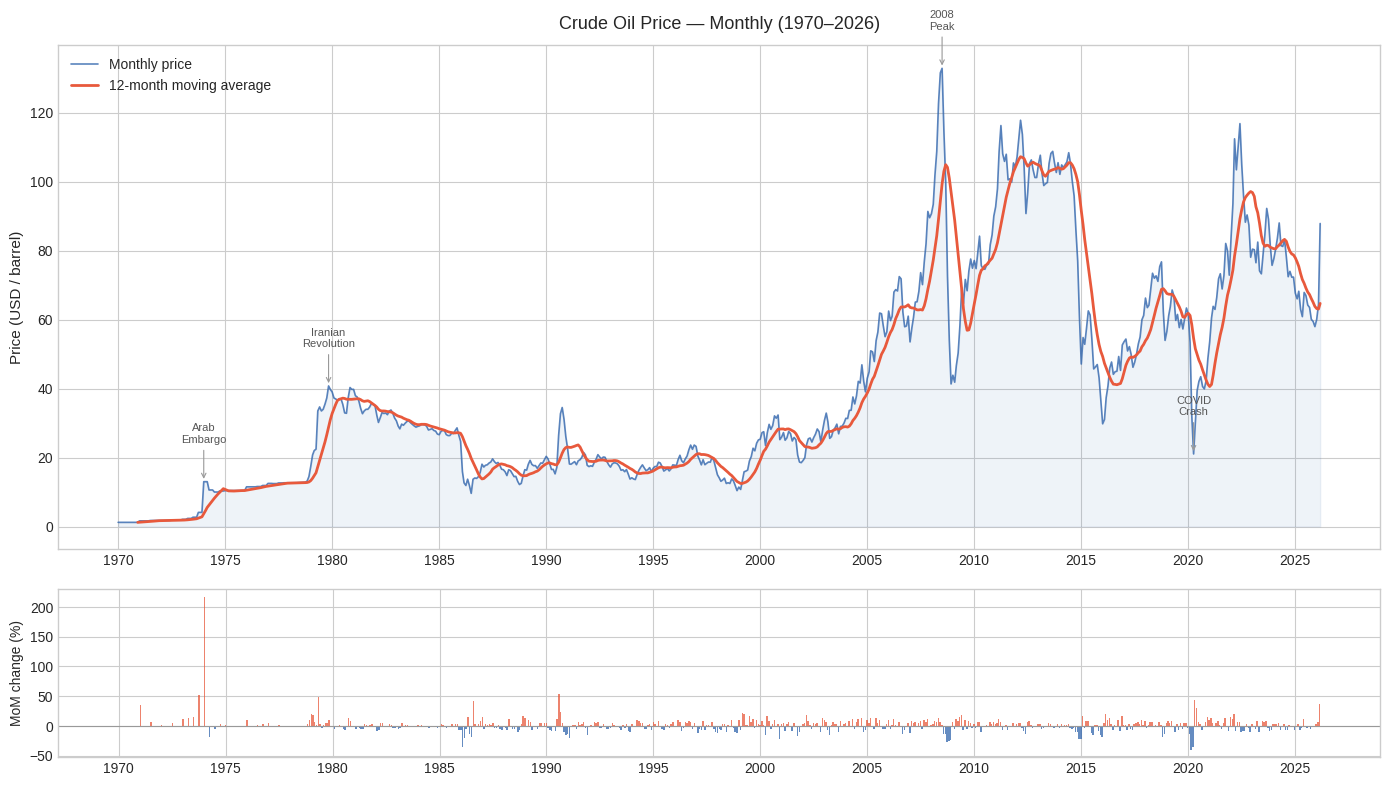


✅ Preview chart saved → /content/drive/MyDrive/crude_oil_project/outputs/figures/00_setup_preview.png


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# ── Top panel: price + moving average ─────────────────────────────────────
ax1 = axes[0]
ax1.plot(df.index, df['price'], color='#3266AD', linewidth=1.2,
         alpha=0.8, label='Monthly price')
ax1.plot(df.index, df['rolling_mean_12'], color='#E8593C', linewidth=2,
         label='12-month moving average')
ax1.fill_between(df.index, df['price'], alpha=0.08, color='#3266AD')
ax1.set_ylabel('Price (USD / barrel)', fontsize=11)
ax1.set_title('Crude Oil Price — Monthly (1970–2026)', fontsize=13, fontweight='medium', pad=12)
ax1.legend(fontsize=10, loc='upper left')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(5))

# Annotate the 4 biggest events
events = [
    ('1974-01-01', 'Arab\nEmbargo'),
    ('1979-11-01', 'Iranian\nRevolution'),
    ('2008-07-01', '2008\nPeak'),
    ('2020-04-01', 'COVID\nCrash'),
]
for date_str, label in events:
    xdate = pd.Timestamp(date_str)
    if xdate in df.index:
        yval = df.loc[xdate, 'price']
        ax1.annotate(label, xy=(xdate, yval),
                     xytext=(0, 28), textcoords='offset points',
                     fontsize=8, color='#555', ha='center',
                     arrowprops=dict(arrowstyle='->', color='#999', lw=0.8))

# ── Bottom panel: month-over-month % change ────────────────────────────────
ax2 = axes[1]
colors = ['#E8593C' if v >= 0 else '#3266AD' for v in df['pct_change'].fillna(0)]
ax2.bar(df.index, df['pct_change'].fillna(0), color=colors,
        width=25, alpha=0.75)
ax2.axhline(0, color='#999', linewidth=0.8)
ax2.set_ylabel('MoM change (%)', fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(5))

plt.tight_layout(h_pad=1.5)

# Save to Drive
fig_path = os.path.join(PATHS['figures'], '00_setup_preview.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Preview chart saved → {fig_path}")

## Step 9 — Save Clean Dataset to Drive

This saves two files:
- `oil_clean.csv` — full enriched dataset, used by all notebooks
- `project_meta.json` — project metadata (date range, stats) for the dashboard

In [10]:
# Save clean CSV
clean_csv_path = os.path.join(PATHS['data'], 'oil_clean.csv')
df.to_csv(clean_csv_path)
print(f"✅ Clean dataset saved  → {clean_csv_path}")

# Save metadata JSON (used later by the Streamlit dashboard)
meta = {
    'date_generated': datetime.now().isoformat(),
    'records': len(df),
    'date_start': str(df.index.min().date()),
    'date_end': str(df.index.max().date()),
    'price_min': round(float(df['price'].min()), 2),
    'price_max': round(float(df['price'].max()), 2),
    'price_mean': round(float(df['price'].mean()), 2),
    'columns': list(df.columns),
}
meta_path = os.path.join(PATHS['root'], 'project_meta.json')
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f"✅ Project metadata saved → {meta_path}")

print()
print("─" * 55)
print("  🎉 Setup complete! Your project is ready.")
print("─" * 55)
print()
print("  Next steps:")
print("  → Open 01_eda.ipynb           (EDA & annotated charts)")
print("  → Open 02_event_analysis.ipynb (geopolitical impact)")
print("  → Open 03_forecasting.ipynb    (ARIMA / Prophet / LSTM)")
print()

✅ Clean dataset saved  → /content/drive/MyDrive/crude_oil_project/data/oil_clean.csv
✅ Project metadata saved → /content/drive/MyDrive/crude_oil_project/project_meta.json

───────────────────────────────────────────────────────
  🎉 Setup complete! Your project is ready.
───────────────────────────────────────────────────────

  Next steps:
  → Open 01_eda.ipynb           (EDA & annotated charts)
  → Open 02_event_analysis.ipynb (geopolitical impact)
  → Open 03_forecasting.ipynb    (ARIMA / Prophet / LSTM)



---
## 🔁 Quick-Start Block (Paste at top of every other notebook)

Copy the cell below into the first code cell of notebooks 01–04.  
It re-mounts Drive, re-imports libraries, and reloads the clean dataset in one shot.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  QUICK-START — paste this at the top of every notebook          ║
# ╚══════════════════════════════════════════════════════════════════╝

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, warnings, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT = '/content/drive/MyDrive/crude_oil_project'
PATHS = {
    'root':      PROJECT_ROOT,
    'data':      os.path.join(PROJECT_ROOT, 'data'),
    'models':    os.path.join(PROJECT_ROOT, 'models'),
    'figures':   os.path.join(PROJECT_ROOT, 'outputs', 'figures'),
    'forecasts': os.path.join(PROJECT_ROOT, 'outputs', 'forecasts'),
}

# Load the clean dataset (saved by 00_project_setup.ipynb)
df = pd.read_csv(
    os.path.join(PATHS['data'], 'oil_clean.csv'),
    index_col='Date', parse_dates=True
)
df.index = pd.DatetimeIndex(df.index, freq='MS')

FIGSIZE = (14, 5)
print(f"✅ Ready. Loaded {len(df)} rows ({df.index.min().date()} → {df.index.max().date()})")